# Parsing mirror figure data from ALS XROL
awojdyla@lbl.gov, ilacey@lbl.gov, NicolasSmith@lbl.gov, vvyashchuk@lbl.gov, March 2026

We want to parse data from XROL to input into Shadow raytracing simulations.

This draws partially on:
https://github.com/ALS-X-Ray-optics/project-redwood/blob/main/notebooks/20260225aiw_ssrl_m0_import.ipynb

In [1]:
filepath = "/Users/awojdyla/data/hhloM1_F219002_IntegratedHeight.dat"
#note:  you may want to remove manually trailing commas in the file.

target = "*Data starts."
line_no = None

with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f, start=1):
        if line.strip() == target:
            line_no = i
            print(f"Found at line {line_no}: {line.strip()}")
            break

if line_no is None:
    print(f'Line "{target}" not found in {filepath}')




Found at line 44: *Data starts.


In [2]:
import numpy as np

# Read numeric grid from CSV (non-numeric entries become NaN)
raw = np.genfromtxt(filepath, delimiter="\t", skip_header=line_no, dtype=float)
mirror_pos_tang_mm = raw[:,0]
mirror_height_nm = raw[:,1]


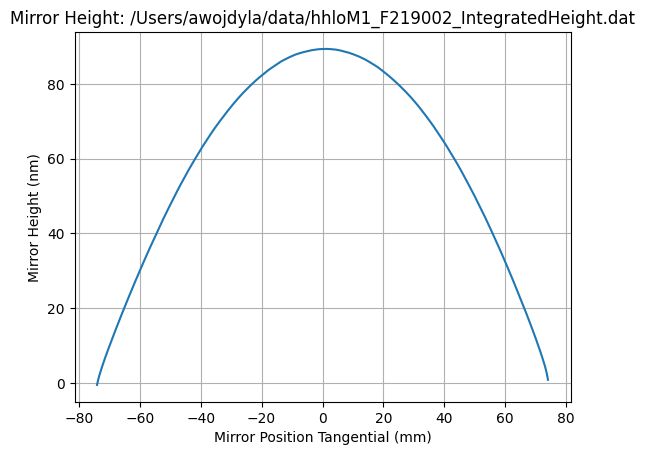

In [3]:
import matplotlib.pyplot as plt
plt.plot(mirror_pos_tang_mm, mirror_height_nm)
plt.xlabel("Mirror Position Tangential (mm)")
plt.ylabel("Mirror Height (nm)")    
plt.title("Mirror Height: %s" % filepath)
plt.grid()
plt.show()  

## convert to Shadow format
It requires an old version of python to run, because we're using an old version of shadow:
```
pip install xraylib
pip install scipy
pip install matplotlib==3.5.3
pip install --upgrade numpy==1.22.4
pip install Shadow3
pip install --upgrade numpy==1.23.5
```

In [4]:
import Shadow

x_m = raw[:,0]*1e-3

# shadow doesn't like 1D arrays, so we need to create a 2D array for y and z
y_m = np.linspace(-0.001,0.001,3)  # example y coordinates, adjust as needed
z_m = np.vstack((raw[:,1],raw[:,1],raw[:,1]))*1e-9
Shadow.ShadowTools.write_shadow_surface(z_m.T, y_m, x_m, outFile = '/Users/awojdyla/data/shadow_hhloM1_F219002_IntegratedHeight.dat') 


write_shadow_surface: File for SHADOW /Users/awojdyla/data/shadow_hhloM1_F219002_IntegratedHeight.dat written to disk.


## Trying with Shadow4
At this point, it seems Shadow4 doesn't have conversion tools in it base package

In [5]:
#!pip install Shadow4

In [6]:
# from shadow4.tools import beamline_tools
# dir(beamline_tools)